In [15]:
import os
import rocqiomics as rq
from rocqiomics.transforms import N4ITKBiasFieldCorrection

from monai.transforms import (
    Compose,
    ScaleIntensityd,
    NormalizeIntensityd,
    Spacingd,
    RandAffined,
    RandGaussianNoised,
)

## Define data_dicts, list of dicts with `image` and `mask` keywords with paths

[{'case_id': 'RGS021425_ph1',
  'image': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Images\\d1_T2_RGS021425_ph1.nrrd',
  'mask': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Masks\\d1_T2_RGS021425_ph1.seg.nrrd',
  'metadata': {'mask_name': 'Snickers', 'modality': 'T2', 'timepoint': 'd1'}}]

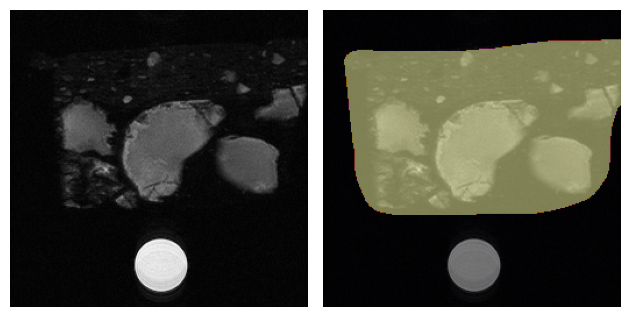

In [16]:
# Only image and mask keywords are required. Use case_id and metadata to keep better track of data in pandas dataframes and saved results.
data_dicts = [
    {
        'case_id' : f'RGS021425_ph{i}',
        'image' : os.path.join(os.getcwd(), 'test_data', 'Images', f'{tp}_T2_RGS021425_ph{i}.nrrd'),
        'mask' : os.path.join(os.getcwd(), 'test_data', 'Masks', f'{tp}_T2_RGS021425_ph{i}.seg.nrrd'),
        'metadata' : {
            'mask_name' : 'Snickers',
            'modality' : 'T2',
            'timepoint' : tp 
        }
    }
for i in range(1,4) for tp in ['d1', 'd5']]

display(data_dicts[0:1])
rq.utils.plot_data_dict(data_dicts[0], rows=1)

## Standard feature extraction with Monai-transform preprocessing

In [17]:
# Use Compose to apply the standard (intensity intensity normalization, re-spacing, etc.) preprocessing transforms to all loaded images/masks
preprocessing_transform = Compose([
        N4ITKBiasFieldCorrection(image_key='image', mask_key='mask', max_iterations=20),
        NormalizeIntensityd(keys=['image']), # Standardize image intensity (subtract mean and divide by standard dev)
        ScaleIntensityd(keys=['image'], factor=99.0, minv=None, maxv=None), # Scale images by factor of 100 (99 + 1)
        Spacingd(keys=['image', 'mask'], pixdim=(0.125, 0.125, 1.0), mode=[3, 'nearest']), # Resample image and mask to specified voxel size
    ])

# Initialize Rocqiomics extractor pipeline
extractor = rq.Rocqiomics(
    load_transform=None, # monai.transforms.LoadImaged(keys=['image', 'mask']) is used by default
    preprocessing=preprocessing_transform,
    augmentations=[], # No augmentation transforms (default)
    features=['Mean', 'Busyness', 'Autocorrelation'], # Default computes all classes,
    extraction_settings_yaml_filepath=None, # Set this path if you want to recover standard Pyradiomics behavior
    bin_width=10.0,
    voxel_based=False,
    engine='pyradiomics',
    save_results=False,
)

# Run for your data
results = extractor.run_pipeline(data_dicts)
results = results.drop(columns=[c for c in results.columns if 'diagnostics' in c])
display(results)

rocqiomics INFO:	 Validating images and masks.
rocqiomics INFO:	 Extraction Pipeline Initialized | Engine: pyradiomics | Cases: 6 | Excluded cases: 0
rocqiomics INFO:	 Case 0/5 done in 0.36s	case_id: RGS021425_ph1	mask_name: Snickers	modality: T2	timepoint: d1	augmentation: 0	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d1_T2_RGS021425_ph1.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Masks\d1_T2_RGS021425_ph1.seg.nrrd
rocqiomics INFO:	 Case 1/5 done in 0.41s	case_id: RGS021425_ph1	mask_name: Snickers	modality: T2	timepoint: d5	augmentation: 0	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d5_T2_RGS021425_ph1.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\P

,original_firstorder_Mean,original_glcm_Autocorrelation,original_ngtdm_Busyness,mask_name,modality,timepoint,augmentation,image_path,mask_path
case_id,,,,,,,,,
RGS021425_ph1,37.04177847553656,241.927640622688,28.510262409079207,Snickers,T2,d1,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,29.280718930733634,186.904136648393,35.890102772206454,Snickers,T2,d5,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph2,37.12041300432013,259.6954896138431,24.07661751989758,Snickers,T2,d1,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph2,37.13404186871259,231.61003506626855,26.010009239669476,Snickers,T2,d5,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph3,46.81463980924595,268.85014585915025,24.411570615922166,Snickers,T2,d1,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph3,52.24070621476833,318.82989111798753,19.781081921187802,Snickers,T2,d5,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...


## Standard feature extraction with Monai-transform preprocessing and augmentation

In [18]:
preprocessing_transform = Compose([
        N4ITKBiasFieldCorrection(image_key='image', mask_key='mask', max_iterations=20),
        NormalizeIntensityd(keys=['image']), # Standardize image intensity (subtract mean and divide by standard dev)
        ScaleIntensityd(keys=['image'], factor=99.0, minv=None, maxv=None), # Scale images by factor of 100 (99 + 1)
        Spacingd(keys=['image', 'mask'], pixdim=(0.125, 0.125, 1.0), mode=[3, 'nearest']), # Resample image and mask to specified voxel size
    ])

# Create 5 augmentation transforms to be applied consisting of small perturbations (affine motions + noise addition)
# Results will contain features from original (un-perturbed images) as well as those from all five perturbations for each iamge
perturbation_transforms = [
    Compose([
        RandAffined(keys=['image', 'mask'], mode=[3, 'nearest'], prob=1.0,
                rotate_range=(0.0, 0.0, 3.0 * 3.1415 / 180), translate_range=(4.0, 4.0, 0.0)
                ),
        RandGaussianNoised(keys=['image'], prob=1, mean=0, std=300, sample_std=True),
    ])
for i in range(5)]

# Initialize Rocqiomics extractor pipeline
extractor = rq.Rocqiomics(
    load_transform=None, # monai.transforms.LoadImaged(keys=['image', 'mask']) is used by default
    preprocessing=preprocessing_transform,
    augmentations=perturbation_transforms, # Apply perturbations
    features=['Mean', 'Busyness', 'Autocorrelation'], # Default: computes all classes
    extraction_settings_yaml_filepath=None, # Set this path if you want to recover standard Pyradiomics behavior
    bin_width=10.0,
    voxel_based=False,
    engine='pyradiomics',
    save_results=False,
)

# Run for your data
results = extractor.run_pipeline(data_dicts)
results = results.drop(columns=[c for c in results.columns if 'diagnostics' in c])
display(results)

rocqiomics INFO:	 Validating images and masks.
rocqiomics INFO:	 Extraction Pipeline Initialized | Engine: pyradiomics | Cases: 36 | Excluded cases: 0
rocqiomics INFO:	 Case 0/35 done in 0.55s	case_id: RGS021425_ph1	mask_name: Snickers	modality: T2	timepoint: d1	augmentation: 0	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d1_T2_RGS021425_ph1.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Masks\d1_T2_RGS021425_ph1.seg.nrrd
rocqiomics INFO:	 Case 1/35 done in 0.82s	case_id: RGS021425_ph1	mask_name: Snickers	modality: T2	timepoint: d1	augmentation: 1	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d1_T2_RGS021425_ph1.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Cente

,original_firstorder_Mean,original_glcm_Autocorrelation,original_ngtdm_Busyness,mask_name,modality,timepoint,augmentation,image_path,mask_path
case_id,,,,,,,,,
RGS021425_ph1,37.04177847553656,241.927640622688,28.510262409079207,Snickers,T2,d1,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,36.87727845411419,241.41752322775437,31.072243610183087,Snickers,T2,d1,1,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,37.15572014207966,242.24942950462582,27.446842016496344,Snickers,T2,d1,2,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,37.30901014648778,242.79697159198042,29.288704340876183,Snickers,T2,d1,3,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,36.742639375649354,268.52135332783007,26.383487249671763,Snickers,T2,d1,4,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,36.526477809715885,240.42810313344978,28.600014745114052,Snickers,T2,d1,5,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,29.280718930733634,186.904136648393,35.890102772206454,Snickers,T2,d5,0,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,28.946510114781866,186.11290643265284,39.14025602724546,Snickers,T2,d5,1,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
RGS021425_ph1,29.393783535242576,187.30773708295598,37.224944447550044,Snickers,T2,d5,2,c:\Users\ri54995\OneDrive - Roswell Park Compr...,c:\Users\ri54995\OneDrive - Roswell Park Compr...
